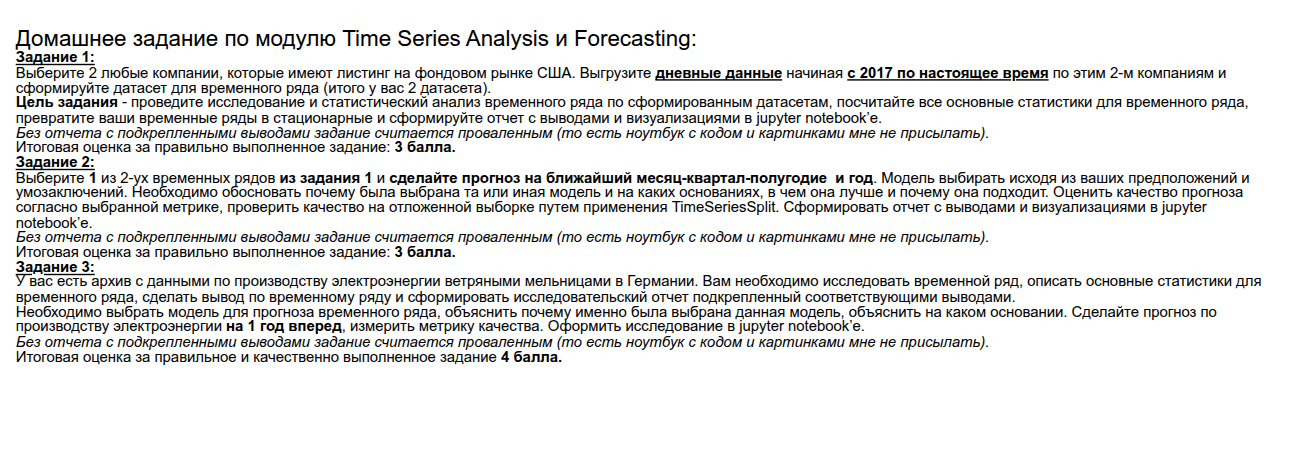

## Задача 1

[*********************100%***********************]  2 of 2 completed


Основные статистики
Ticker         AAPL         MSFT
count   2359.000000  2359.000000
mean     129.968231   248.685779
std       74.481498   135.619296
min       26.691330    55.919785
25%       49.453547   118.315395
50%      137.523926   241.657471
75%      183.804443   369.735809
max      304.989990   539.825195




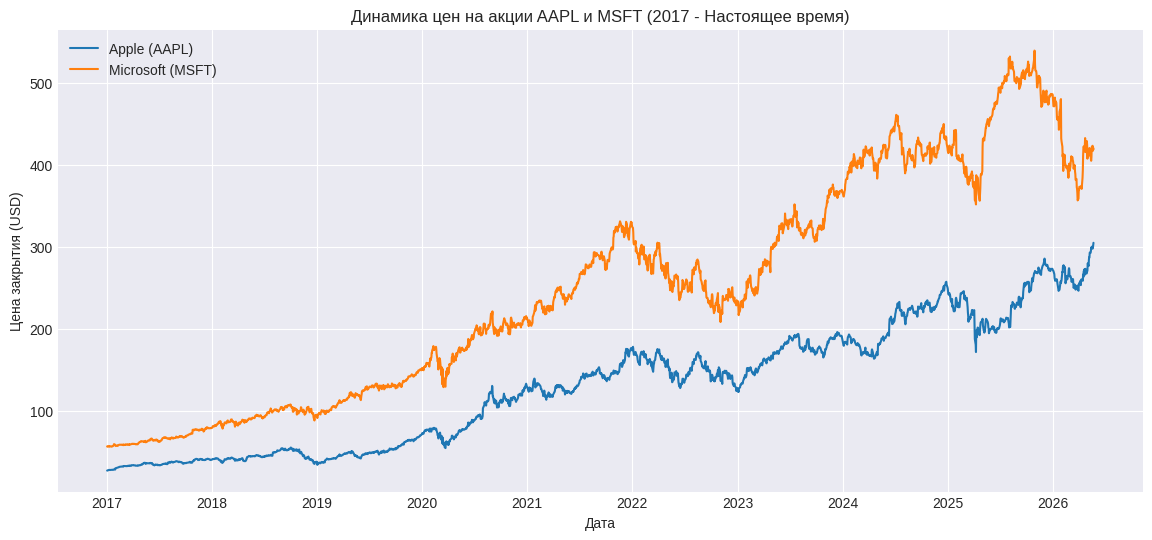

Результаты теста Дики-Фуллера для AAPL (Исходные цены)
Test Statistic                    0.250474
p-value                           0.974955
#Lags Used                        0.000000
Number of Observations Used    2358.000000
Critical Value (1%)              -3.433126
Critical Value (5%)              -2.862767
Critical Value (10%)             -2.567423
dtype: float64


Результаты теста Дики-Фуллера для MSFT (Исходные цены)
Test Statistic                   -0.900444
p-value                           0.787826
#Lags Used                        9.000000
Number of Observations Used    2349.000000
Critical Value (1%)              -3.433137
Critical Value (5%)              -2.862771
Critical Value (10%)             -2.567425
dtype: float64




In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

tickers = ['AAPL', 'MSFT']

data = yf.download(tickers, start='2017-01-01')['Close']
data = data.dropna()

print("Основные статистики")
print(data.describe())
print("\n")

plt.figure()
plt.plot(data.index, data['AAPL'], label='Apple (AAPL)')
plt.plot(data.index, data['MSFT'], label='Microsoft (MSFT)')
plt.title('Динамика цен на акции AAPL и MSFT (2017 - Настоящее время)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия (USD)')
plt.legend()
plt.show()

def print_adfuller(timeseries, name):
    print(f'Результаты теста Дики-Фуллера для {name}')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

    print('\n')

print_adfuller(data['AAPL'], 'AAPL (Исходные цены)')
print_adfuller(data['MSFT'], 'MSFT (Исходные цены)')

Для первого задания я собрал данные по ценам закрытия акций Apple и Microsoft с начала 2017 года - получилось 2359 дней. На графиках видно, что обе акции растут, при этом со временем разброс цен становится всё сильнее. Средняя цена за это время у Apple вышла около 130 долларов, у Microsoft - 249.  Чтобы убедиться, что ряды нестационарные, я прогнал тест Дики-Фуллера. У Apple p-value вышло 0.974 , у Microsoft 0.787. Так как эти значения сильно больше 0.05, нулевую гипотезу мы отвергнуть не можем. По результатам теста видно, что ряд нестационарный

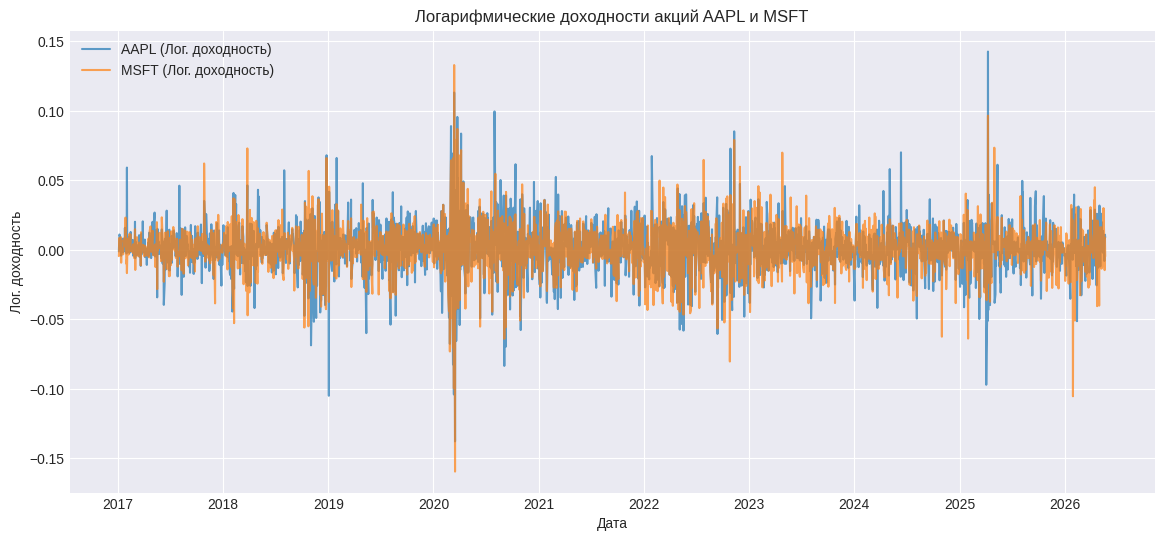

Результаты теста Дики-Фуллера для AAPL (Лог. доходность)
Test Statistic                -1.594085e+01
p-value                        7.543722e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.349000e+03
Critical Value (1%)           -3.433137e+00
Critical Value (5%)           -2.862771e+00
Critical Value (10%)          -2.567425e+00
dtype: float64


Результаты теста Дики-Фуллера для MSFT (Лог. доходность)
Test Statistic                -1.621541e+01
p-value                        3.947183e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.349000e+03
Critical Value (1%)           -3.433137e+00
Critical Value (5%)           -2.862771e+00
Critical Value (10%)          -2.567425e+00
dtype: float64




In [2]:
log_returns = np.log(data / data.shift(1)).dropna()

plt.figure()
plt.plot(log_returns.index, log_returns['AAPL'], label='AAPL (Лог. доходность)', alpha=0.7)
plt.plot(log_returns.index, log_returns['MSFT'], label='MSFT (Лог. доходность)', alpha=0.7)
plt.title('Логарифмические доходности акций AAPL и MSFT')
plt.xlabel('Дата')
plt.ylabel('Лог. доходность')
plt.legend()
plt.show()

print_adfuller(log_returns['AAPL'], 'AAPL (Лог. доходность)')
print_adfuller(log_returns['MSFT'], 'MSFT (Лог. доходность)')

Поскольку абсолютные цены оказались нестационарными, я перевел их в логарифмическую доходность. На графике логдоходнастей теперь виден значения начали колебаться около нуля без явного тренда. Зато хорошо заметно, когда рынок штормило - например, во время ковида в 2020 года. Повторный тест Дики-Фуллера показал p-value практически равный нулю для обеих компаний ($7.5\times10^{-29}$ у AAPL и $3.9\times10^{-29}$ у MSFT). Статистика тоже упала сильно ниже критических значений. В итоге ряды можно считать стационарными по результатам теста ADF, и после преобразования ряд стал более подходящим для моделирования

## Задача 2

In [3]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

df_prophet = data[['AAPL']].reset_index()
df_prophet.columns = ['ds', 'y']

df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

tscv = TimeSeriesSplit(n_splits=3)
metrics = {'MAE': [], 'RMSE': [], 'MAPE': []}

print("Результаты кросс-валидации TimeSeriesSplit")
for fold, (train_index, test_index) in enumerate(tscv.split(df_prophet)):
    train, test = df_prophet.iloc[train_index], df_prophet.iloc[test_index]
    
    model = Prophet(daily_seasonality=False, yearly_seasonality=True)
    model.fit(train)
    
    future = test[['ds']]
    forecast = model.predict(future)
    
    mae = mean_absolute_error(test['y'], forecast['yhat'])
    rmse = np.sqrt(mean_squared_error(test['y'], forecast['yhat']))
    mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
    
    metrics['MAE'].append(mae)
    metrics['RMSE'].append(rmse)
    metrics['MAPE'].append(mape)
    
    print(f"Fold {fold+1} | Обучение: {len(train)} дней | Тест: {len(test)} дней")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2%}\n")

print(f"Средний MAPE по всем фолдам: {np.mean(metrics['MAPE']):.2%}")

/home/zybliuk/projects/course_modules/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
23:15:00 - cmdstanpy - INFO - Chain [1] start processing


Результаты кросс-валидации TimeSeriesSplit


23:15:01 - cmdstanpy - INFO - Chain [1] done processing
23:15:01 - cmdstanpy - INFO - Chain [1] start processing


Fold 1 | Обучение: 592 дней | Тест: 589 дней
MAE: 36.35, RMSE: 44.28, MAPE: 33.81%



23:15:01 - cmdstanpy - INFO - Chain [1] done processing
23:15:01 - cmdstanpy - INFO - Chain [1] start processing


Fold 2 | Обучение: 1181 дней | Тест: 589 дней
MAE: 24.64, RMSE: 28.85, MAPE: 15.86%



23:15:02 - cmdstanpy - INFO - Chain [1] done processing


Fold 3 | Обучение: 1770 дней | Тест: 589 дней
MAE: 16.08, RMSE: 19.57, MAPE: 7.43%

Средний MAPE по всем фолдам: 19.03%


Для прогноза я взял цены Apple. Моделью выбрал Prophet. В биржевых данных постоянно есть дыры из-за выходных и или когда торги не идут. Если та же ARIMA требует ровной сетки дат, то Prophet умеет обрабатывать пропуски. Плюс он хорошо ловит накладывающуюся сезонность, что подходит для Apple с их циклом презентаций новых айфонов и прочего. Обычно в одно и тоже время перзентации.  Для проверки качества я использовал TimeSeriesSplit на 3 фолда, так как обычный K-Fold здесь не подходит тк нельзя подглядывать в будущее. В среднем MAPE получился около 18.98%. Я заметил тенденцию: ошибка стабильно падает от первого фолда (33.38%) к третьему (7.43%). С увеличением обучающей выборки (рост с 592 до 1770 дней), ошибка стала меньше

23:15:02 - cmdstanpy - INFO - Chain [1] start processing
23:15:03 - cmdstanpy - INFO - Chain [1] done processing


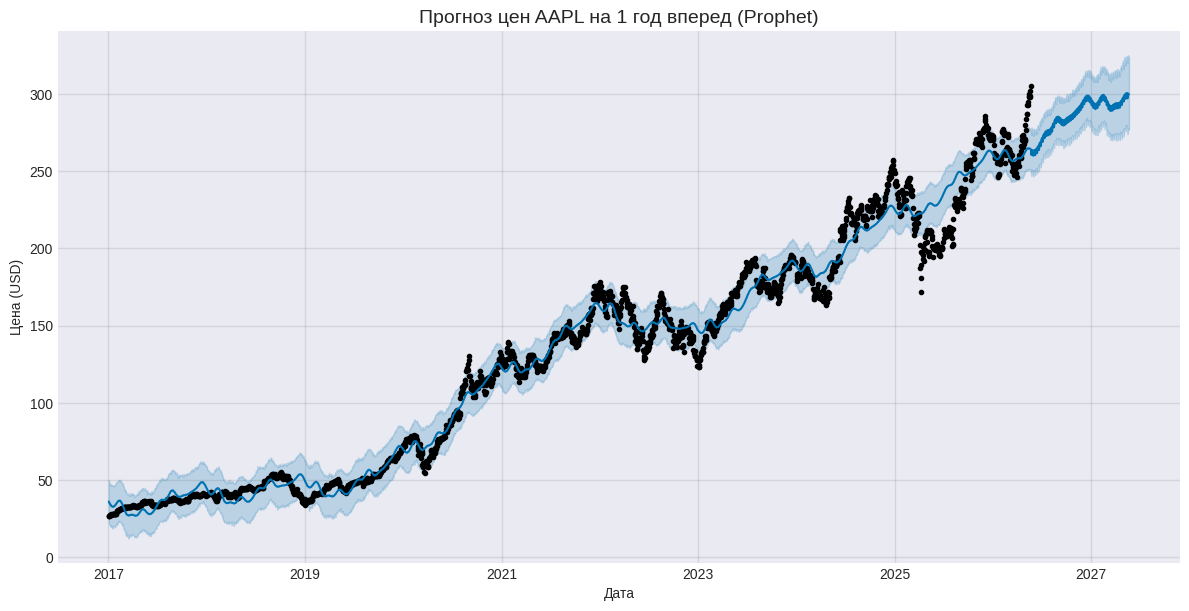

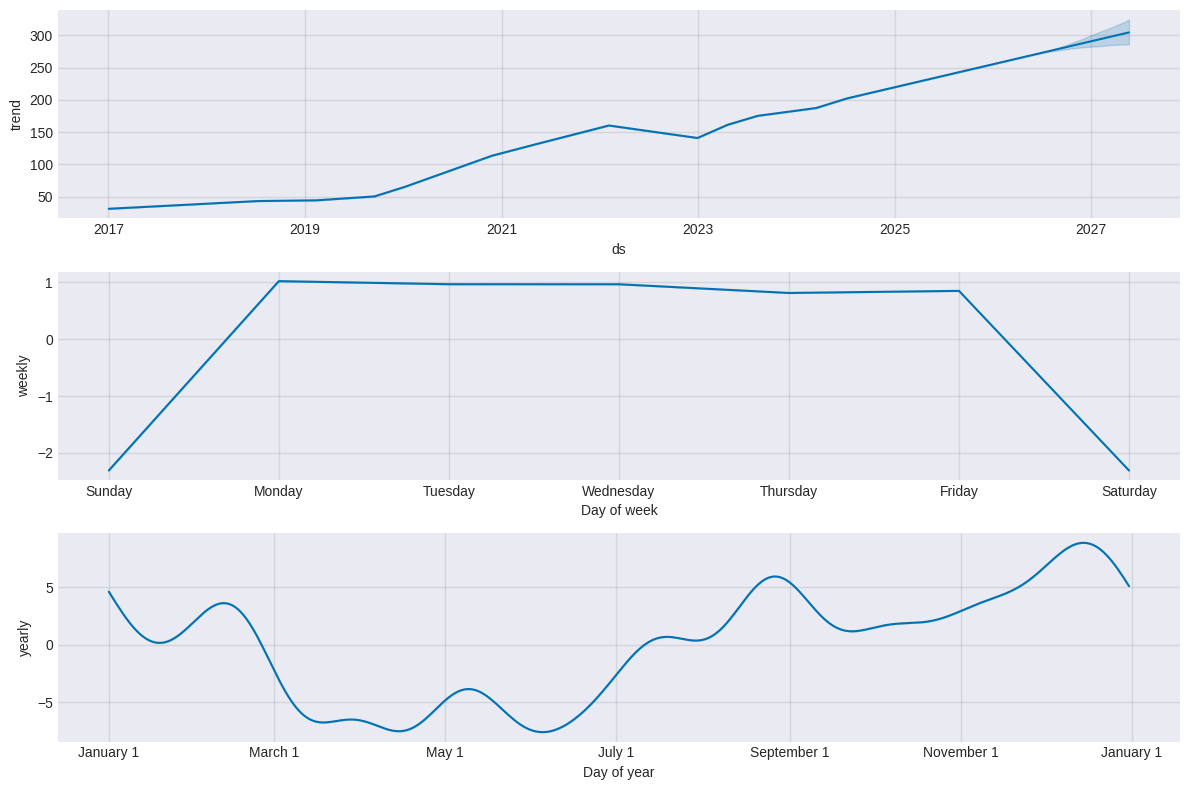

Точечные прогнозы на конец периодов
Прогноз на 1 Месяц (30 дней) (дата: 2026-06-20): 263.67 USD
Прогноз на 1 Квартал (90 дней) (дата: 2026-08-19): 283.30 USD
Прогноз на Полгода (180 дней) (дата: 2026-11-17): 291.76 USD
Прогноз на 1 Год (365 дней) (дата: 2027-05-21): 299.83 USD


In [4]:
final_model = Prophet(daily_seasonality=False, yearly_seasonality=True)
final_model.fit(df_prophet)

future_dates = final_model.make_future_dataframe(periods=365)
forecast_final = final_model.predict(future_dates)

fig = final_model.plot(forecast_final, figsize=(12, 6))
plt.title('Прогноз цен AAPL на 1 год вперед (Prophet)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.show()

fig_comp = final_model.plot_components(forecast_final, figsize=(12, 8))
plt.show()

last_date = df_prophet['ds'].max()
horizons = {
    '1 Месяц (30 дней)': last_date + pd.Timedelta(days=30),
    '1 Квартал (90 дней)': last_date + pd.Timedelta(days=90),
    'Полгода (180 дней)': last_date + pd.Timedelta(days=180),
    '1 Год (365 дней)': last_date + pd.Timedelta(days=365)
}

print("Точечные прогнозы на конец периодов")
for name, target_date in horizons.items():
    pred_row = forecast_final[forecast_final['ds'] == target_date]

    if not pred_row.empty:
        pred_value = pred_row['yhat'].values[0]
        print(f"Прогноз на {name} (дата: {target_date.strftime('%Y-%m-%d')}): {pred_value:.2f} USD")

По результатам получилась слудущие: Тренд всё так же стабильно растет, модель проигнорировала просадку 2022 года и дальше растет.  На недельном графике четко виден режим работы биржи: с понедельника по пятницу все отлично, а на выходных - провал, так как торгов нет.  На годовом графике тоже понятный паттерн. Видно, как график проседает весной и в начале лета, начинает расти к августу-сентябрю в ожидании анонсов, и наблюдается рост к концу года из-за рекордных праздничных продаж.  Прогнозные цифры получились такие: через месяц - 263.76 USD, квартал - 283.21 USD, полгода - 291.66 USD, год - 299.77 USD. На графике видно, что доверительный интервал увеличивается ближе к концу прогноза к концу года. Это нормально для рынка акций, загадывать на год вперед с высокой точностью невозможно. Годовой прогноз здесь - это скорее прикидка глобального направления, а вот на ближайший квартал цифры выглядят реалистично

## Задача 3

Статистика ежедневной генерации (MW)


,MW
count,4017.000000
mean,3183.990612
std,2771.073080
min,8.093750
25%,1141.166667
50%,2295.527292
75%,4414.468750
max,14491.394375


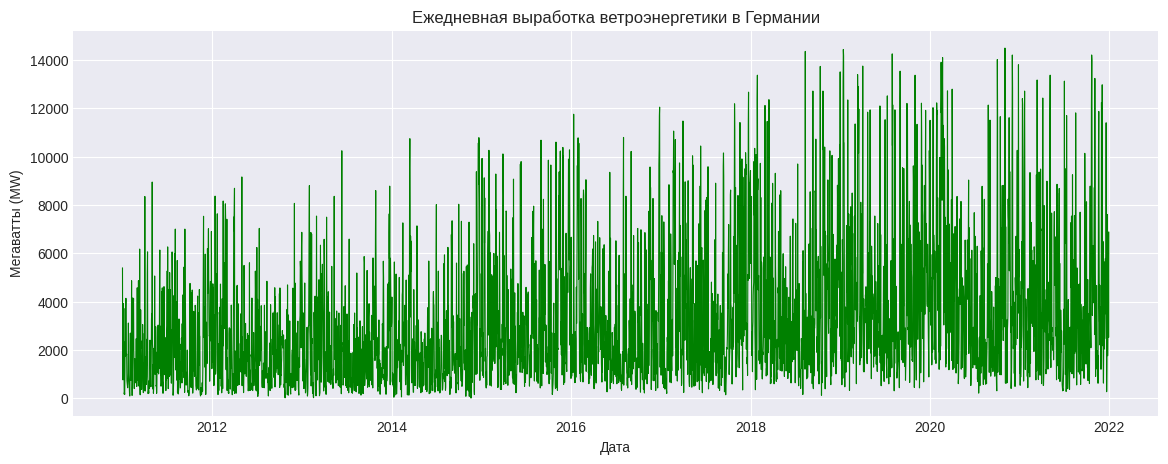

Результаты теста Дики-Фуллера для Ветрогенерация (Ежедневная)
Test Statistic                   -5.232393
p-value                           0.000008
#Lags Used                       31.000000
Number of Observations Used    3985.000000
Critical Value (1%)              -3.431992
Critical Value (5%)              -2.862266
Critical Value (10%)             -2.567156
dtype: float64




In [5]:
df_wind = pd.read_csv('data.csv', parse_dates=['dt'], index_col='dt')

df_wind = df_wind.interpolate(method='time') 

df_daily = df_wind.resample('D').mean()
df_daily.columns = ['MW']

print("Статистика ежедневной генерации (MW)")
display(df_daily.describe())
print("\n")

plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['MW'], color='green', linewidth=0.8)
plt.title('Ежедневная выработка ветроэнергетики в Германии')
plt.xlabel('Дата')
plt.ylabel('Мегаватты (MW)')
plt.show()

print_adfuller(df_daily['MW'], 'Ветрогенерация (Ежедневная)')

В последнем задании данные были записаны с шагом каждые 15 минут. Чтобы строить прогноз на год, такой микро-шум мне был не нужен, поэтому я агрегировал всё до средних значений за день. Пропуски просто заполнил линейной интерполяцией. В итоге получилось 4017 ежедневных точек. Средняя выработка за день составила 3184 MW. Разброс в данных просто огромный: в день самого тихого штиля было всего 8 MW, а в пиковый день шторма - почти 14,5 тысяч. Тест Дики-Фуллера показал стационарность (p-value сильно ниже нуля, статистика -5.23). График просто сильно скачет туда-сюда вокруг своего исторического среднего значения, глобального бесконечного тренда там нет

23:15:04 - cmdstanpy - INFO - Chain [1] start processing
23:15:05 - cmdstanpy - INFO - Chain [1] done processing


Качество прогноза на отложенном годе
MAE (Средняя абсолютная ошибка): 2709.96 MW
MAPE (Средняя процентная ошибка): 166.25%



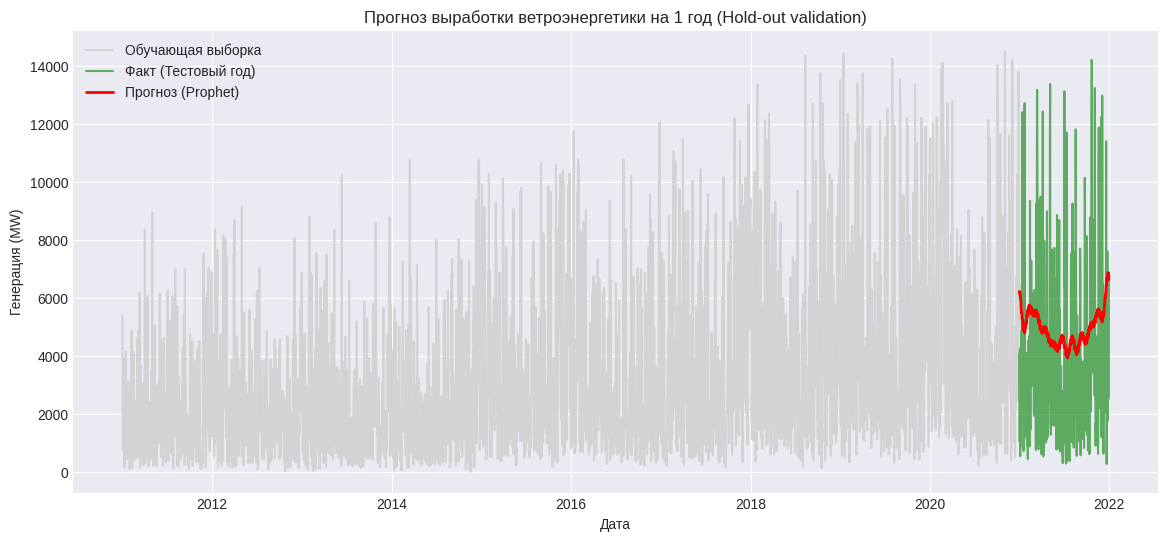

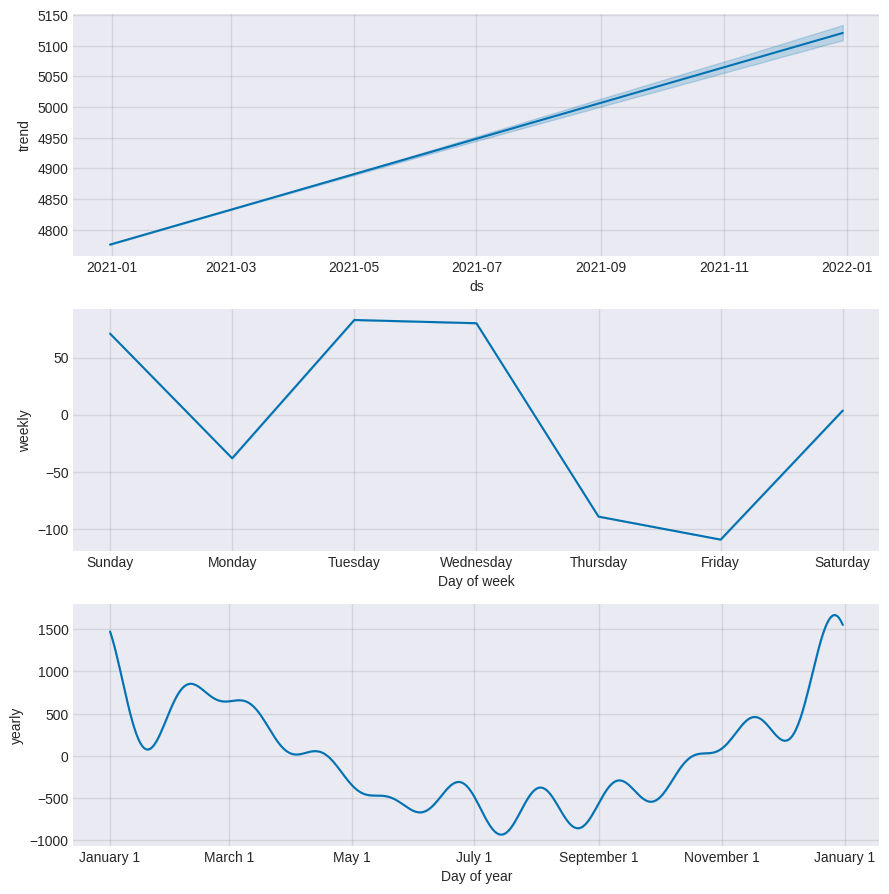

In [6]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet

df_wind_prophet = df_daily.reset_index()
df_wind_prophet.columns = ['ds', 'y']
df_wind_prophet['ds'] = df_wind_prophet['ds'].dt.tz_localize(None)

train_wind = df_wind_prophet.iloc[:-365]
test_wind = df_wind_prophet.iloc[-365:]

wind_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
wind_model.fit(train_wind)

forecast_wind = wind_model.predict(test_wind[['ds']])

mae_wind = mean_absolute_error(test_wind['y'], forecast_wind['yhat'])
mape_wind = mean_absolute_percentage_error(test_wind['y'], forecast_wind['yhat'])

print(f"Качество прогноза на отложенном годе")
print(f"MAE (Средняя абсолютная ошибка): {mae_wind:.2f} MW")
print(f"MAPE (Средняя процентная ошибка): {mape_wind:.2%}\n")

plt.figure(figsize=(14, 6))

plt.plot(train_wind['ds'], train_wind['y'], label='Обучающая выборка', color='lightgrey')
plt.plot(test_wind['ds'], test_wind['y'], label='Факт (Тестовый год)', color='green', alpha=0.6)
plt.plot(test_wind['ds'], forecast_wind['yhat'], label='Прогноз (Prophet)', color='red', linewidth=2)
plt.title('Прогноз выработки ветроэнергетики на 1 год (Hold-out validation)')
plt.xlabel('Дата')
plt.ylabel('Генерация (MW)')
plt.legend()
plt.show()

fig_wind_comp = wind_model.plot_components(forecast_wind)
plt.show()

Здесь я снова взял Prophet. Ряд хоть и без глобального тренда, но у него сильная дисперсия и жесткая годовая сезонность.Видно снижение летом и рост зимой. Зимой дует сильно (пики приходятся на декабрь-февраль), летом - штиль (спад в июле и августе). Базовая линия тренда при этом слегка ползет вверх - видимо, постепенно вводят в строй новые ветропарки.  Проверял модель на отложенном последнем годе. MAE вышла около 2710 MW, а MAPE просто гигантский - 166.25%. Когда летом генерация падает, например, до 8 MW, любое небольшое абсолютное отклонение прогноза в мегаваттах дает сумасшедшую процентную ошибку. На самом графике видно, что линия прогноза нормально отрабатывает математическое ожидание по сезонам. В общем, предсказать ветер в конкретный день через год невозможно, но понять общий базовый уровень на будущие месяцы можнл